In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sklearn.linear_model import LinearRegression, HuberRegressor, QuantileRegressor,SGDRegressor

## 1.Loss Function Model Regression

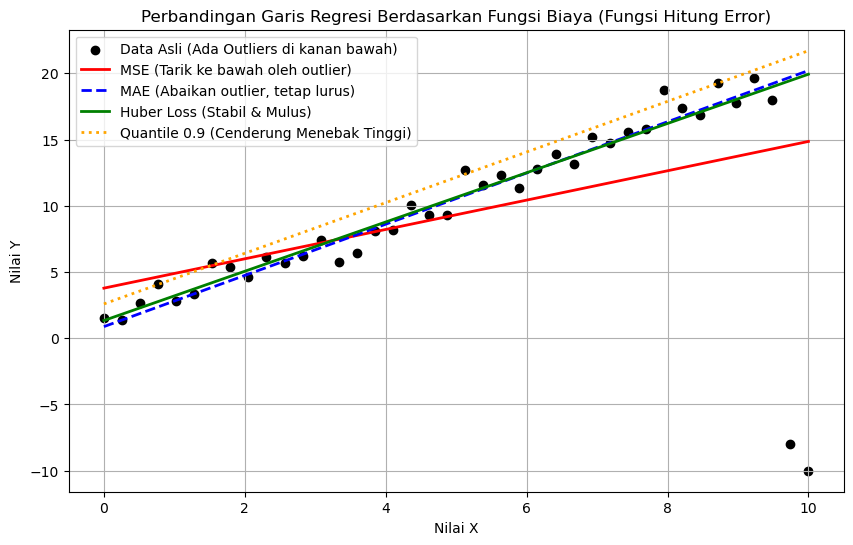

In [6]:
# 1. Membuat data tiruan (Dummy Data)
np.random.seed(42)
X = np.linspace(0, 10, 40).reshape(-1, 1)
# Hubungan asli: y = 2x + 1 + sedikit noise
y = 2 * X.squeeze() + 1 + np.random.normal(0, 1, int(40))

# 2. Menambahkan DATA PENCILAN (Outliers) secara sengaja
# Kita ubah data terakhir menjadi sangat ngawur nilainya
y[-1] = -10  
y[-2] = -8

# --- PENERAPAN BERBAGAI FUNGSI BIAYA ---

# A. Regresi Linear Standar (Menggunakan MSE / Least Squares)
model_mse = LinearRegression()
model_mse.fit(X, y)
pred_mse = model_mse.predict(X)

# B. Huber Regressor (Gabungan MSE + MAE, kebal outliers)
model_huber = HuberRegressor(epsilon=1.35) # epsilon adalah batas toleransi delta
model_huber.fit(X, y)
pred_huber = model_huber.predict(X)

# C. Quantile Regressor (Menggunakan MAE jika quantile=0.5)
# Catatan: QuantileRegressor menggunakan MAE di scikit-learn jika diset 0.5
model_mae = QuantileRegressor(quantile=0.5, alpha=0)
model_mae.fit(X, y)
pred_mae = model_mae.predict(X)

# D. Quantile Regressor (Memihak - Batas Atas / Quantile 0.9)
# Model ini akan lebih takut jika tebakannya kekecilan
model_q90 = QuantileRegressor(quantile=0.9, alpha=0)
model_q90.fit(X, y)
pred_q90 = model_q90.predict(X)


# 3. Visualisasi Hasil Perbandingan
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='black', label='Data Asli (Ada Outliers di kanan bawah)')

plt.plot(X, pred_mse, color='red', linewidth=2, label='MSE (Tarik ke bawah oleh outlier)')
plt.plot(X, pred_mae, color='blue', linewidth=2, linestyle='--', label='MAE (Abaikan outlier, tetap lurus)')
plt.plot(X, pred_huber, color='green', linewidth=2, label='Huber Loss (Stabil & Mulus)')
plt.plot(X, pred_q90, color='orange', linewidth=2, linestyle=':', label='Quantile 0.9 (Cenderung Menebak Tinggi)')

plt.title('Perbandingan Garis Regresi Berdasarkan Fungsi Biaya (Fungsi Hitung Error)')
plt.xlabel('Nilai X')
plt.ylabel('Nilai Y')
plt.legend()
plt.grid(True)
plt.show()

## 2.Optimazation Model Regression

Grafik visualisasi sedang diproses...


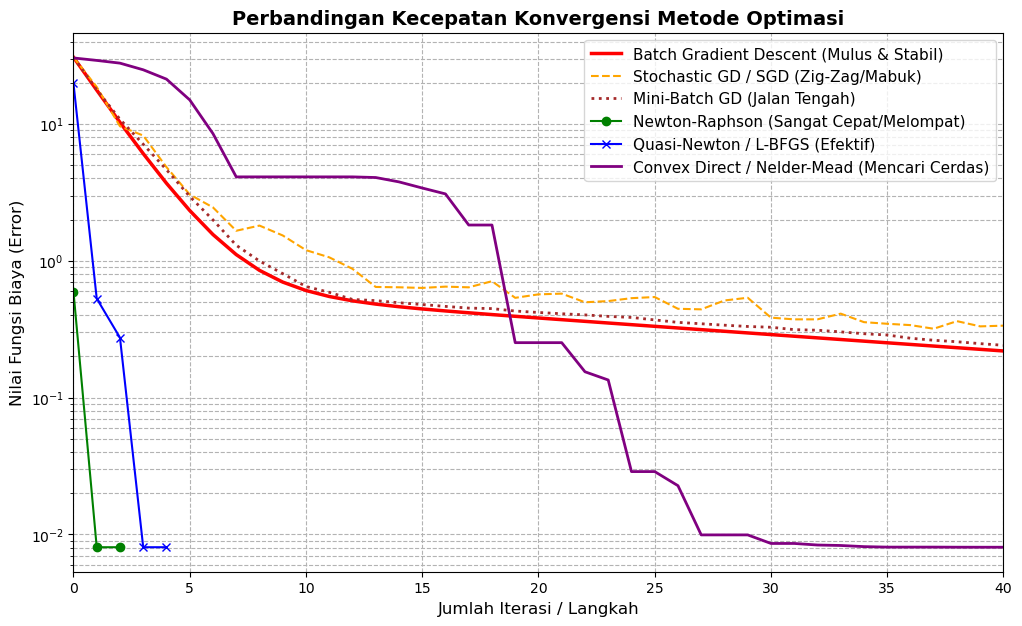

In [7]:
# 1. Membuat Data Tiruan
np.random.seed(42)
X = np.random.rand(100, 1)
y = (3 * X + 2 + np.random.randn(100, 1) * 0.1).squeeze()
X_b = np.c_[np.ones((100, 1)), X]

# Fungsi untuk menghitung Mean Squared Error (Fungsi Biaya)
def compute_cost(theta):
    return np.mean((X_b.dot(theta) - y) ** 2)

# Titik awal tebakan acak yang SAMA untuk semua metode
initial_theta = np.array([-1.0, -2.0])

# Tempat menyimpan histori nilai error/cost tiap iterasi
history_bgd = []
history_sgd = []
history_mbgd = []
history_newton = []
history_quasi = []
history_convex = []

# ==========================================
# A. BATCH GRADIENT DESCENT (Histori)
# ==========================================
theta = initial_theta.copy()
lr = 0.1
for i in range(50):
    history_bgd.append(compute_cost(theta))
    gradients = 2/len(X_b) * X_b.T.dot(X_b.dot(theta) - y)
    theta = theta - lr * gradients

# ==========================================
# B. STOCHASTIC GRADIENT DESCENT (Histori)
# ==========================================
theta = initial_theta.copy()
lr = 0.1
for i in range(50):
    history_sgd.append(compute_cost(theta))
    # Ambil 1 data acak
    random_index = np.random.randint(len(X_b))
    xi = X_b[random_index:random_index+1]
    yi = y[random_index:random_index+1]
    gradients = 2 * xi.T.dot(xi.dot(theta) - yi)
    theta = theta - lr * gradients

# ==========================================
# C. MINI-BATCH GRADIENT DESCENT (Histori)
# ==========================================
theta = initial_theta.copy()
lr = 0.1
batch_size = 20
for i in range(50):
    history_mbgd.append(compute_cost(theta))
    shuffled_indices = np.random.permutation(len(X_b))
    X_b_s = X_b[shuffled_indices]
    y_s = y[shuffled_indices]
    # Ambil satu kelompok batch
    xi = X_b_s[0:batch_size]
    yi = y_s[0:batch_size]
    gradients = 2/batch_size * xi.T.dot(xi.dot(theta) - yi)
    theta = theta - lr * gradients

# ==========================================
# D, E, F. METODE SCIPY (Newton, Quasi, Convex)
# ==========================================
# Karena SciPy langsung mencari hasil akhir, kita gunakan callback function 
# untuk merekam nilai cost di setiap langkah internalnya.

def jacobian(theta): return 2/len(X_b) * X_b.T.dot(X_b.dot(theta) - y)
def hessian(theta): return 2/len(X_b) * X_b.T.dot(X_b)

minimize(compute_cost, x0=initial_theta, jac=jacobian, hess=hessian, method='Newton-CG', callback=lambda x: history_newton.append(compute_cost(x)))
minimize(compute_cost, x0=initial_theta, jac=jacobian, method='L-BFGS-B', callback=lambda x: history_quasi.append(compute_cost(x)))
minimize(compute_cost, x0=initial_theta, method='Nelder-Mead', callback=lambda x: history_convex.append(compute_cost(x)))


# ==========================================
# VISUALISASI MENGGUNAKAN MATPLOTLIB
# ==========================================
plt.figure(figsize=(12, 7))

# Plot masing-masing histori optimasi
plt.plot(history_bgd, label='Batch Gradient Descent (Mulus & Stabil)', color='red', linewidth=2.5)
plt.plot(history_sgd, label='Stochastic GD / SGD (Zig-Zag/Mabuk)', color='orange', linewidth=1.5, linestyle='--')
plt.plot(history_mbgd, label='Mini-Batch GD (Jalan Tengah)', color='brown', linewidth=2, linestyle=':')
plt.plot(history_newton, label='Newton-Raphson (Sangat Cepat/Melompat)', color='green', marker='o', markersize=6)
plt.plot(history_quasi, label='Quasi-Newton / L-BFGS (Efektif)', color='blue', marker='x', markersize=6)
plt.plot(history_convex, label='Convex Direct / Nelder-Mead (Mencari Cerdas)', color='purple', linewidth=2)

plt.title('Perbandingan Kecepatan Konvergensi Metode Optimasi', fontsize=14, fontweight='bold')
plt.xlabel('Jumlah Iterasi / Langkah', fontsize=12)
plt.ylabel('Nilai Fungsi Biaya (Error)', fontsize=12)
plt.yscale('log') # Menggunakan skala logaritma agar perbedaan di bawah terlihat jelas
plt.xlim(0, 40)   # Kita batasi 40 iterasi awal agar grafiknya fokus
plt.grid(True, which="both", ls="--", c='0.7')
plt.legend(fontsize=11)

print("Grafik visualisasi sedang diproses...")
plt.show()